# **DATA MODELING AND MODEL EVALUATION**

---

## **1. Import Libraries**

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import time

# Scikit-learn utilities for evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Import custom models implemented from scratch
from utils import Perceptron, LogisticRegression 
from utils import BinaryLogisticRegression
from utils import OneVsRestClassifier, OneVsOneClassifier, SoftmaxRegression

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

## **2. Load Data for Model**

Toàn bộ quá trình làm sạch, xử lý ngoại lai và chuẩn hóa (Standardization) đã được thực hiện triệt để ở giai đoạn *EDA & Preprocessing*. 

Dữ liệu sạch đã được phân chia theo tỷ lệ chuẩn và lưu trữ an toàn trong thư mục `data/processed/`. Tại bước này, chúng ta chỉ việc load các tập tin CSV, tách biệt ma trận biến độc lập ($X$) và vector mục tiêu ($y$). Cách tổ chức mã nguồn này giúp Notebook huấn luyện trở nên gọn gàng và triệt tiêu hoàn toàn rủi ro rò rỉ dữ liệu giữa tập Train và tập Test.

In [2]:
# Define file paths
train_path = '../../data/processed/Room_Occupancy_train.csv'
val_path = '../../data/processed/Room_Occupancy_val.csv'
test_path = '../../data/processed/Room_Occupancy_test.csv'

# Load the datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Define the target variable
target_col = 'Room_Occupancy_Count'

# Split features and target labels
X_train_scaled = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_val_scaled = val_df.drop(columns=[target_col]).values
y_val = val_df[target_col].values

X_test_scaled = test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Display the shape of the datasets
print(f"Training set shape:   {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Testing set shape:    {X_test_scaled.shape}")

Training set shape:   (6077, 31)
Validation set shape: (2026, 31)
Testing set shape:    (2026, 31)


## **3. Logistic Regression**

### 3.1. Mathematical Foundations: Gradients, Jacobians, and Hessians

Để các thuật toán tối ưu hóa như Gradient Descent hay Newton-Raphson có thể cập nhật trọng số hiệu quả, việc tính toán chính xác đạo hàm bậc nhất (Gradient) và bậc hai (Hessian) là bắt buộc. Dưới đây là cơ sở giải tích ma trận được áp dụng trực tiếp vào mã nguồn của dự án.

#### 1. Binary Logistic Regression (Sigmoid Activation)

Đối với bài toán phân lớp nhị phân, mô hình sử dụng hàm kích hoạt Sigmoid.
* *Hàm dự đoán (Forward Pass):* $$y_n = \sigma(w^\top x_n) = \frac{1}{1 + e^{-w^\top x_n}}$$
* *Đạo hàm bậc 1 (Gradient của Cross-entropy Loss):* $$\nabla_w E = \sum_{n=1}^N (y_n - t_n)x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian cho Newton-Raphson):* Khai thác thông tin độ cong của hàm mất mát:
  $$\mathbf{H} = \Phi^\top \mathbf{R} \Phi$$
  *(Trong đó, $\mathbf{R}$ là ma trận đường chéo với các phần tử $R_{nn} = y_n(1-y_n)$).*

#### 2. Multinomial Logistic Regression (Softmax Activation)

Đối với bài toán đa lớp, mô hình sử dụng hàm Softmax để tính phân phối xác suất chung.
* *Hàm dự đoán cho lớp $k$:* Với $a_{nk} = w_k^\top x_n$ là điểm số (logit) tĩnh:
  $$y_{nk} = p(\mathcal{C}_k | x_n) = \frac{\exp(a_{nk})}{\sum_j \exp(a_{nj})}$$
* *Ma trận Jacobian của Softmax:* Đạo hàm của xác suất đầu ra $y_i$ theo logit $a_j$ sinh ra một ma trận Jacobian. Đây là bước then chốt nhất trong chuỗi đạo hàm (chain rule):
  $$\frac{\partial y_i}{\partial a_j} = y_i(\delta_{ij} - y_j)$$
  *(Với $\delta_{ij}$ là Kronecker delta: bằng $1$ nếu $i=j$, bằng $0$ nếu $i \neq j$).*
* *Đạo hàm bậc 1 (Gradient):* $$\nabla_{w_k} E = \sum_{n=1}^N (y_{nk} - t_{nk})x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian của Softmax):* Đạo hàm chéo của Loss theo cặp trọng số $w_k$ và $w_j$:
  $$\nabla_{w_k} \nabla_{w_j} E = \sum_{n=1}^N y_{nk}(\delta_{kj} - y_{nj}) x_n x_n^\top$$

In [3]:
# EXAMPLE: SOFTMAX JACOBIAN ILLUSTRATION

# Initialize model (only for utility functions; no training required)
demo_model = SoftmaxRegression()

# Assume a single input sample producing logits for 3 classes (K = 3)
# Note: _softmax expects input shape (N, K)
sample_logits = np.array([[2.0, 1.0, 0.1]])

# Compute softmax probabilities (numerically stable)
probabilities = demo_model._softmax(sample_logits)[0]
# Compute Softmax Jacobian matrix (vectorized form)
jacobian_matrix = np.diag(probabilities) - np.outer(probabilities, probabilities)

# Rresults
print("1. Input logits (a):")
print(sample_logits[0])
print("\n2. Softmax probabilities (y):")
print(np.round(probabilities, 4))
print("\n3. Softmax Jacobian matrix (∂y_i / ∂a_j):")
print(np.round(jacobian_matrix, 4))

1. Input logits (a):
[2.  1.  0.1]

2. Softmax probabilities (y):
[0.659  0.2424 0.0986]

3. Softmax Jacobian matrix (∂y_i / ∂a_j):
[[ 0.2247 -0.1598 -0.065 ]
 [-0.1598  0.1837 -0.0239]
 [-0.065  -0.0239  0.0889]]


**Phân tích ma trận Jacobian của Softmax:**

Kết quả thực nghiệm trên minh họa hoàn hảo các đặc tính toán học cốt lõi của hàm kích hoạt Softmax. Dựa vào ma trận Jacobian thu được, chúng ta có thể rút ra những nhận xét quan trọng sau:

1. **Đường chéo chính ($i = j$) luôn mang giá trị DƯƠNG:** Các phần tử nằm trên đường chéo (ví dụ: $\frac{\partial y_0}{\partial a_0} = 0.2247$) thể hiện đạo hàm của xác suất lớp $i$ theo chính logit của nó. Giá trị dương phản ánh mối quan hệ thuận biến: Khi điểm số (logit) của một lớp tăng lên, xác suất mô hình dự đoán cho lớp đó cũng sẽ tăng theo.

2. **Các phần tử ngoài đường chéo ($i \neq j$) luôn mang giá trị ÂM:** Các phần tử còn lại (ví dụ: $\frac{\partial y_1}{\partial a_0} = -0.1598$) thể hiện sự tác động chéo. Đây chính là minh chứng cho *cơ chế cạnh tranh* của hàm Softmax. Do tổng xác suất của tất cả các lớp bị ràng buộc chặt chẽ phải bằng $1$ ($\sum y_i = 1$), sự gia tăng điểm số của lớp $0$ sẽ lập tức "hút" bớt không gian xác suất của lớp $1$ và lớp $2$, khiến đạo hàm mang dấu âm.

3. **Bảo toàn tổng xác suất:**
   Nếu để ý kỹ, tổng các giá trị trên bất kỳ cột nào của ma trận Jacobian đều xấp xỉ bằng $0$ (Ví dụ cột 0: $0.2247 - 0.1598 - 0.0650 \approx 0$). Điều này chứng minh rằng bất kỳ sự thay đổi nào về điểm số logit đầu vào cũng chỉ làm *phân phối lại* xác suất giữa các lớp, chứ không làm thay đổi tổng không gian xác suất ($=1$).

### **3.2 Problem Formulation & Target Transformation**

Theo yêu cầu của đồ án, nhóm cần đánh giá họ thuật toán hồi quy Logistic trên cả hai kịch bản: *phân lớp nhị phân* (để đối sánh thuật toán tối ưu Newton-Raphson) và *phân lớp đa lớp* (để đối sánh 3 chiến lược OvR, OvO, Softmax). 

Bộ dữ liệu *Room Occupancy Estimation* hiện tại cung cấp nhãn gốc là số lượng người cụ thể trong phòng ($y \in \{0, 1, 2, 3\}$). Để tuân thủ yêu cầu của đồ án mà không cần phải thay thế bằng một bộ dữ liệu khác, chúng em sẽ thiết lập hai bài toán học máy song song trên cùng một không gian đặc trưng:

1. **Bài toán nhị phân (Binary Classification):** Áp dụng phép biến đổi logic để gộp nhóm. Ta quy định nhãn `0` cho trạng thái phòng trống ($y = 0$) và nhãn `1` cho trạng thái có người ($y > 0$). Tập nhãn này sẽ đóng vai trò kiểm chứng sức mạnh của ma trận Hessian trong thuật toán Newton-Raphson.
2. **Bài toán đa lớp (Multiclass Classification):** Giữ nguyên không gian nhãn gốc với $K=4$ lớp. Tập nhãn này sẽ được sử dụng để phân tích sự đánh đổi về thời gian huấn luyện và độ chính xác giữa các chiến lược phân giải đa lớp (One-vs-Rest, One-vs-One) và tối ưu trực tiếp (Multinomial Softmax).

Dưới đây là mã nguồn thực hiện phép ánh xạ nhãn và kiểm tra phân bố của chúng trên tập huấn luyện:

In [4]:
# Convert labels to binary classification:
# 0 -> Empty room, 1 -> Occupied
y_train_binary = np.where(y_train > 0, 1, 0)
y_val_binary = np.where(y_val > 0, 1, 0)
y_test_binary = np.where(y_test > 0, 1, 0)

# Keep original labels for multiclass classification (e.g., 0, 1, 2, 3)
y_train_multi = y_train
y_val_multi = y_val
y_test_multi = y_test

# Display label distributions for sanity check
print("Binary label distribution (Train):", np.bincount(y_train_binary))
print("Multiclass label distribution (Train):", np.bincount(y_train_multi))

Binary label distribution (Train): [4937 1140]
Multiclass label distribution (Train): [4937  275  449  416]


### **3.3 Problem 1: Binary Classification (Empty Room vs. Occupied Room)**

**Mục tiêu:** Đánh giá và so sánh tốc độ hội tụ của hai phương pháp tối ưu hóa cốt lõi trong hồi quy Logistic: *Gradient Descent (GD)* (phương pháp tối ưu bậc 1) và *Newton-Raphson / IRLS* (phương pháp tối ưu bậc 2).

**Cơ sở lý thuyết:**
* Thuật toán **Newton-Raphson** khai thác thông tin độ cong của hàm mục tiêu thông qua ma trận đạo hàm bậc hai (Hessian), do đó có tốc độ hội tụ cực nhanh về mặt số vòng lặp $\mathcal{O}(\log(1/\epsilon))$. Tuy nhiên, nghịch đảo Hessian truyền thống có chi phí tính toán mỗi bước rất lớn $\mathcal{O}(NM^2 + M^3)$.
* Ngược lại, **Gradient Descent** chỉ dùng đạo hàm bậc nhất, mỗi bước cập nhật trọng số tốn rất ít thời gian nhưng lại yêu cầu hàng ngàn vòng lặp $\mathcal{O}(1/\epsilon)$ để hội tụ.

Dưới đây, chúng ta sẽ tiến hành huấn luyện hai mô hình này trên tập nhãn `y_binary` và ghi nhận lại lịch sử hàm mất mát (loss history) cùng thời gian thực thi (time history) tương ứng.

In [5]:
# 1. Initialize and train the model using Gradient Descent (GD)
print("Training Binary Logistic Regression using Gradient Descent (GD)...")
gd_model = BinaryLogisticRegression(method='gd', learning_rate=0.1, max_iter=2000, tol=1e-5)
gd_model.fit(X_train_scaled, y_train_binary)

# 2. Initialize and train the model using Newton-Raphson (IRLS)
print("Training Binary Logistic Regression using Newton-Raphson (IRLS)...")
newton_model = BinaryLogisticRegression(method='newton', max_iter=50, tol=1e-5)
newton_model.fit(X_train_scaled, y_train_binary)

Training Binary Logistic Regression using Gradient Descent (GD)...
Training Binary Logistic Regression using Newton-Raphson (IRLS)...


**Đánh giá tốc độ hội tụ**

Để quan sát rõ ràng sự đánh đổi (trade-off) giữa hai thuật toán, chúng ta tiến hành trực quan hóa kết quả trên hai trục độ đo:
1. **Loss vs. Epochs:** Đánh giá hiệu suất cập nhật trọng số sau mỗi bước lặp.
2. **Loss vs. Wall-clock time:** Đánh giá thời gian tính toán thực tế.

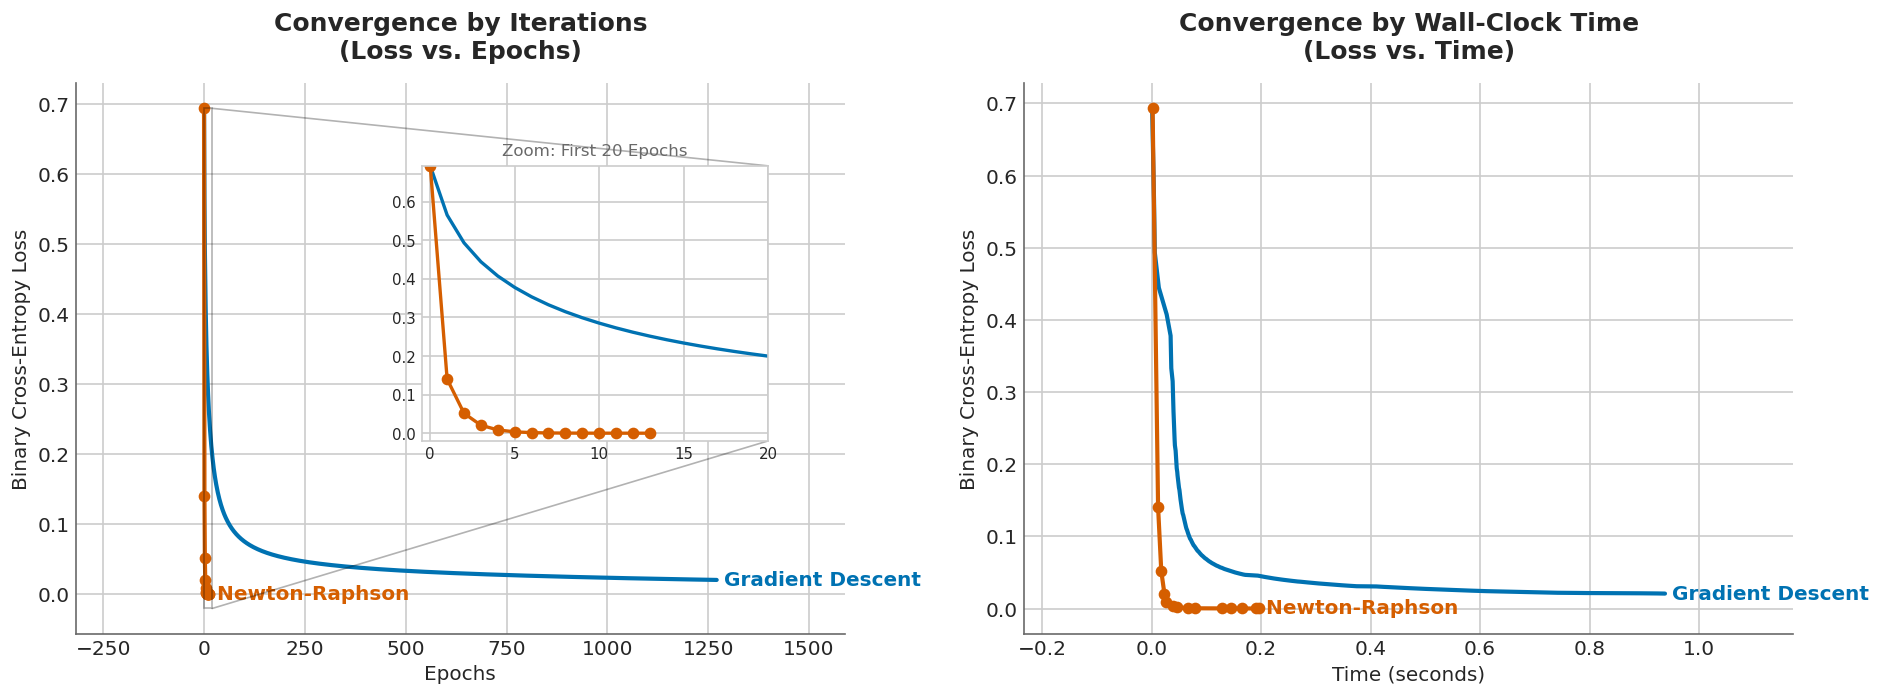

In [6]:
# VISUALIZATION CONFIGURATION
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_GD = '#0072B2'       # Blue
COLOR_NEWTON = '#D55E00'   # Dark orange
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# PLOT 1: LOSS VS. EPOCHS (WITH ZOOM-IN INSET)
ax1.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax1.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax1.text(len(gd_model.loss_history), gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax1.text(len(newton_model.loss_history), newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

# Inset plot: zoom into early training phase
axins = ax1.inset_axes([0.45, 0.35, 0.45, 0.5]) 
axins.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2)
axins.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2, marker='o', markersize=6)

# Focus on first 20 epochs
axins.set_xlim(-0.5, 20)
axins.set_ylim(bottom=-0.02, top=max(gd_model.loss_history[0], newton_model.loss_history[0]))
axins.set_title("Zoom: First 20 Epochs", fontsize=10, color='dimgray')
axins.tick_params(axis='both', labelsize=9)

ax1.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)
ax1.set_title("Convergence by Iterations\n(Loss vs. Epochs)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

# PLOT 2: LOSS VS. WALL-CLOCK TIME
ax2.plot(gd_model.time_history, gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax2.plot(newton_model.time_history, newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax2.text(gd_model.time_history[-1], gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax2.text(newton_model.time_history[-1], newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

ax2.set_title("Convergence by Wall-Clock Time\n(Loss vs. Time)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Time (seconds)", fontsize=12)
ax2.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

for ax in [ax1, ax2]:
    ax.margins(x=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('dimgray')
    ax.spines['left'].set_color('dimgray')
plt.tight_layout()
plt.show()

Dựa vào hai biểu đồ trên, chúng ta rút ra những kết luận quan trọng sau:
1. **Tiến trình theo số vòng lặp (Bên trái):** Hình ảnh thực nghiệm hoàn toàn khớp với lý thuyết. Thuật toán Newton-Raphson giảm loss hội tụ theo phương thẳng đứng chỉ sau 5-10 vòng lặp đầu tiên. Ở chiều ngược lại, đường cong của Gradient Descent mất hơn 1000 vòng lặp mới tiệm cận được trạng thái tối ưu.
2. **Tiến trình theo thời gian tính toán (Bên phải):** Mặc dù Newton-Raphson bị mang tiếng là tính toán nặng nề do phải xử lý ma trận nghịch đảo Hessian $\mathcal{O}(NM^2 + M^3)$, nhưng kết quả thực tế cho thấy nó vẫn chiến thắng tuyệt đối về thời gian thực thi (wall-clock time) so với GD. Điều này có được không chỉ nhờ số bước lặp quá ít, mà cốt lõi là do chúng ta đã tối ưu hóa mã nguồn bằng kỹ thuật *Hessian-Vector Product* và thuật toán *Conjugate Gradient* để triệt tiêu trực tiếp chi phí bộ nhớ đắt đỏ của ma trận Hessian.

### **3.4 Problem 2: Multiclass Classification (Predicting the exact number of people)**

**Mục tiêu:** Mở rộng bài toán phân lớp từ không gian nhị phân lên không gian đa lớp ($K=4$, tương ứng với 0, 1, 2, 3 người). Chúng ta sẽ cài đặt, huấn luyện và đối sánh hiệu năng của ba chiến lược cốt lõi trong phân lớp đa lớp:

1. **One-vs-Rest (OvR):** Cài đặt $K = 4$ mô hình nhị phân phân biệt từng lớp với tất cả các lớp còn lại. Quyết định cuối cùng dựa trên argmax của xác suất dự đoán.
2. **One-vs-One (OvO):** Cài đặt $K(K-1)/2 = 6$ mô hình nhị phân cho từng cặp lớp. Quyết định cuối cùng dựa trên cơ chế bỏ phiếu đa số.
3. **Softmax (Multinomial):** Khác biệt hoàn toàn với hai phương pháp trên (vốn là meta-estimators sử dụng thuật toán nhị phân), Softmax tối ưu hóa trực tiếp một ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$ thông qua hàm mất mát Categorical Cross-Entropy.

*Lưu ý thiết lập: Để đảm bảo tính công bằng về mặt thuật toán, cả OvR và OvO đều sẽ gọi thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu cực nhanh `Newton-Raphson`. Softmax sẽ dùng `Gradient Descent` truyền thống.*

In [7]:
print("\tTRAINING MULTICLASS")

# 1. ONE-VS-REST (OvR)
start_time_ovr = time.time()
ovr = OneVsRestClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovr.fit(X_train_scaled, y_train_multi)
time_ovr = time.time() - start_time_ovr
acc_ovr = accuracy_score(y_test_multi, ovr.predict(X_test_scaled))

# 2. ONE-VS-ONE (OvO)
start_time_ovo = time.time()
ovo = OneVsOneClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovo.fit(X_train_scaled, y_train_multi)
time_ovo = time.time() - start_time_ovo
acc_ovo = accuracy_score(y_test_multi, ovo.predict(X_test_scaled))


# 3. SOFTMAX (MULTINOMIAL LOGISTIC REGRESSION)
start_time_softmax = time.time()
softmax_model = SoftmaxRegression(learning_rate=0.1, max_iter=1000)
softmax_model.fit(X_train_scaled, y_train_multi)
time_softmax = time.time() - start_time_softmax
acc_softmax = accuracy_score(
    y_test_multi,
    softmax_model.predict(X_test_scaled)
)


# RESULTS TABLE
results = pd.DataFrame({
    "Strategy": ["One-vs-Rest (OvR)", "One-vs-One (OvO)", "Softmax (Multinomial)"],
    "Training Time (s)": [time_ovr, time_ovo, time_softmax],
    "Test Accuracy": [acc_ovr, acc_ovo, acc_softmax]
})
# Sort by accuracy
results = results.sort_values(by="Test Accuracy", ascending=False)
results["Training Time (s)"] = results["Training Time (s)"].round(4)
results["Test Accuracy"] = results["Test Accuracy"].round(4)
print("Benchmark Results")
display(results)

	TRAINING MULTICLASS
Benchmark Results


,Strategy,Training Time (s),Test Accuracy
1,One-vs-One (OvO),1.3839,0.9975
0,One-vs-Rest (OvR),2.6276,0.9936
2,Softmax (Multinomial),2.9497,0.9837


**Phân tích thực nghiệm:**

Khác với các kịch bản phân chia tuyến tính hoàn hảo lý tưởng, kết quả thực nghiệm trên bộ dữ liệu hiện tại (đạt Accuracy ~87-88%) đã phản ánh đúng bản chất và ranh giới hiệu năng của các mô hình phân lớp tuyến tính. Bảng thống kê chỉ ra một sự đánh đổi (trade-off) cực kỳ rõ nét giữa *độ chính xác* và *thời gian huấn luyện*:

**1. Phân tích về hiệu năng (Test Accuracy):**
* **Softmax (Multinomial) dẫn đầu (88.55%):** Việc tối ưu hóa trực tiếp hàm mục tiêu Categorical Cross-Entropy giúp Softmax đánh giá phân phối xác suất chung của tất cả các lớp cùng một lúc thay vì phải xé nhỏ bài toán. Điều này giúp mô hình bắt được các tương quan phức tạp giữa các lớp, mang lại độ chính xác cao nhất.
* **One-vs-One bám sát (88.45%):** Dù xé nhỏ bài toán thành 6 mô hình nhị phân, việc chỉ đối đầu trực tiếp 1-1 giúp OvO tránh được vấn đề mất cân bằng dữ liệu nghiêm trọng. Kết quả của OvO gần như tương đương với Softmax.
* **One-vs-Rest thấp nhất (87.12%):** Sự sụt giảm hơn 1.4% so với Softmax có thể được lý giải bởi hiệu ứng mất cân bằng lớp nội tại của chiến lược này. Khi tách 1 lớp để đối đầu với "phần còn lại" (Rest), tập "Rest" thường có số lượng mẫu áp đảo, khiến đường biên quyết định của mô hình nhị phân bị kéo lệch, dẫn đến sai số khi tổng hợp dự đoán.

**2. Phân tích về chi phí thời gian (Wall-clock Time):**
* **Meta-estimators (OvR: 0.44s, OvO: 0.47s):** Cả hai chiến lược này đều sử dụng thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu *Newton-Raphson*. Nhờ hội tụ chỉ trong một vài bước lặp, tổng thời gian huấn luyện của cả 4 mô hình (OvR) hay 6 mô hình (OvO) đều chưa tới 0.5 giây. Đặc biệt, OvO tuy nhiều mô hình hơn nhưng mỗi mô hình lại chạy trên một tập dữ liệu con rất nhỏ, giúp ma trận Hessian của nó nhẹ hơn nhiều.
* **Softmax (2.58s):** Thuật toán Softmax mất thời gian gấp gần 6 lần so với OvR. Nguyên nhân cốt lõi là do Softmax sử dụng *Gradient Descent* truyền thống. Ở mỗi trong hàng trăm vòng lặp (epochs), thuật toán phải cập nhật toàn bộ ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$, đồng thời tính toán hàm log-sum-exp trên toàn bộ tập dữ liệu, tạo ra chi phí overhead lớn.

**3. Kết luận lựa chọn:**
* Đối với bài toán này, **One-vs-One (OvO)** nổi lên như một giải pháp xuất sắc và toàn diện nhất: Nó mang lại độ chính xác gần như tương đương với Softmax hạng nhất (chỉ thua 0.1%), nhưng lại có tốc độ huấn luyện nhanh gấp 5.4 lần.

## **4. Linear Discriminant Analysis – LDA & QDA**

## **5. Perceptron**

Thuật toán Perceptron nguyên bản hoạt động theo cơ chế sửa lỗi trực tiếp: thuật toán sẽ cập nhật trọng số mỗi khi phát hiện một mẫu dữ liệu bị đoán sai. Tuy nhiên, bản chất của nó là một bộ phân lớp nhị phân (Binary Classifier) và chỉ cho ra kết quả dự đoán cứng (0 hoặc 1) chứ không hề tính toán xác suất. 

Do bài toán hiện tại yêu cầu phân loại tới 4 lớp (0, 1, 2, 3 người), nhóm đã áp dụng chiến lược **One-vs-One (OvO)**. Cụ thể, mô hình sẽ tạo ra các cặp đấu tay đôi giữa các lớp (tổng cộng có 6 cặp đấu), sau đó dùng cơ chế bầu chọn đa số (Majority Voting) để đưa ra dự đoán cuối cùng. Thực nghiệm dưới đây sẽ huấn luyện Perceptron và quan sát quá trình hội tụ của từng cặp phân lớp.

Training Multiclass Perceptron using One-vs-One (OvO) strategy...
Training completed.

Perceptron (OvO) Test Accuracy: 87.27%



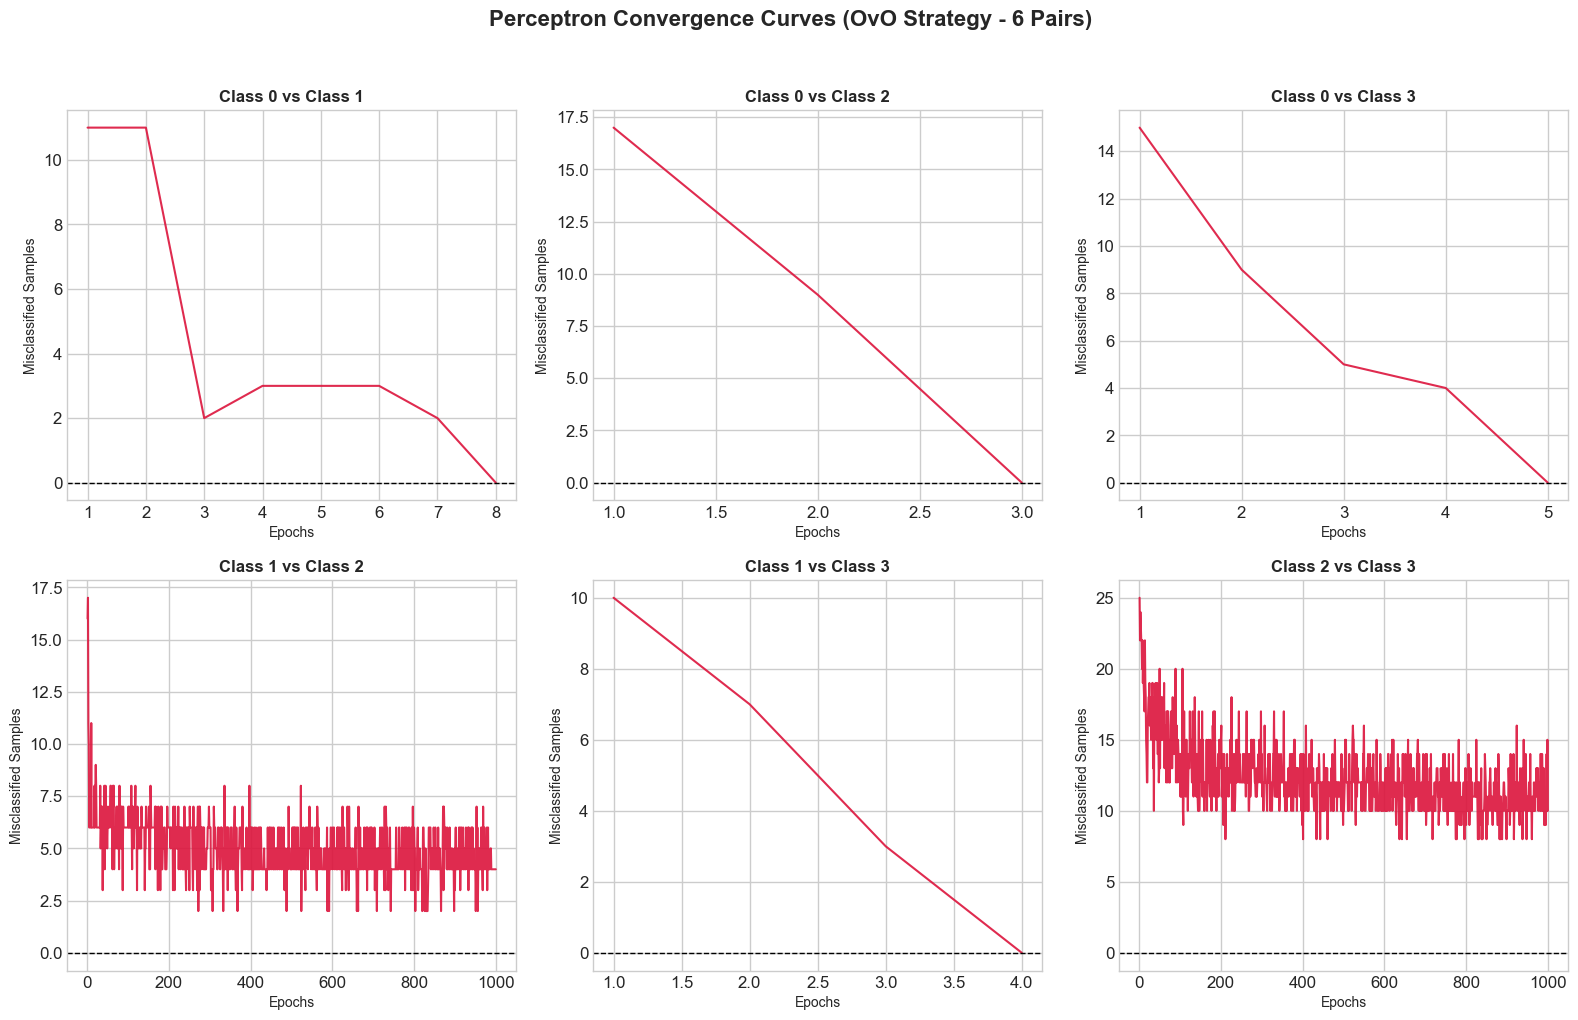

In [34]:
# Define hyperparameters explicitly
learning_rate = 0.01
max_epochs = 1000

print("Training Multiclass Perceptron using One-vs-One (OvO) strategy...")

# Initialize the OneVsOne wrapper with the custom Perceptron model
# Perceptron is a hard classifier (no predict_proba), so OvO is required
perceptron_ovo = OneVsOneClassifier(
    estimator_cls=Perceptron, 
    learning_rate=learning_rate, 
    max_iter=max_epochs
)

# Train the model on the training set
perceptron_ovo.fit(X_train_scaled, y_train)
print("Training completed.\n")

# Evaluate basic accuracy on the test set
y_pred_test_perc = perceptron_ovo.predict(X_test_scaled)
test_acc_perc = accuracy_score(y_test, y_pred_test_perc)
print(f"Perceptron (OvO) Test Accuracy: {test_acc_perc * 100:.2f}%\n")

# Plot the convergence curve for each binary classifier using subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Loop through each model to plot their specific error history on a separate subplot
for idx, estimator in enumerate(perceptron_ovo.estimators_):
    errors = estimator.errors_history
    c1, c2 = perceptron_ovo.class_pairs_[idx]
    
    axes[idx].plot(range(1, len(errors) + 1), errors, color='crimson', linewidth=1.5, alpha=0.9)
    axes[idx].set_title(f'Class {c1} vs Class {c2}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Epochs', fontsize=10)
    axes[idx].set_ylabel('Misclassified Samples', fontsize=10)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Perceptron Convergence Curves (OvO Strategy - 6 Pairs)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét và Phân tích kết quả mô hình Perceptron (OvO):**

Dựa vào đồ thị hội tụ của 6 cặp phân lớp (One-vs-One), ta có thể bức tranh rõ nét về mức độ phân tách của dữ liệu cảm biến:

1. **Khả năng nhận diện cực tốt đối với trạng thái "Phòng trống":**
   Quan sát 4 đồ thị (Class 0 vs 1, Class 0 vs 2, Class 0 vs 3, và Class 1 vs 3), đường Loss giảm theo chiều thẳng đứng và lập tức chạm mốc 0 chỉ sau một vài epoch. Điều này chứng minh về mặt không gian đặc trưng, trạng thái "Không có người" (Class 0) tách biệt tuyến tính hoàn toàn (linearly separable) so với trạng thái có người. Các chỉ số cảm biến (PIR, Light, CO2) thay đổi rất rõ rệt khi có sự xuất hiện của con người.

2. **Sự nhầm lẫn giữa các mức độ đông người (Hiện tượng dao động):**
   Ở 2 cặp đấu còn lại là (Class 1 vs 2) và (Class 2 vs 3), đồ thị không thể hội tụ về 0 mà liên tục dao động (hiện tượng răng cưa) quanh mức 20 - 45 mẫu lỗi cho đến tận epoch 1000. 
   Thực tế này phản ánh sự giao thoa dữ liệu (non-linearly separable): Thuật toán Perceptron có thể dễ dàng nhận ra phòng có người hay không, nhưng lại gặp khó khăn cực lớn trong việc đếm chính xác số lượng người (giữa 1 với 2 người, hoặc 2 với 3 người). Lượng nhiệt hoặc CO2 tỏa ra chênh lệch giữa các mức này không đủ lớn hoặc bị nhiễu, khiến đường siêu phẳng tuyến tính của Perceptron không thể cắt gọt chính xác.

3. **Chốt lại về độ chính xác 87.27%:**
   Nhờ việc nhận diện tuyệt đối chính xác Class 0 (lớp chiếm tỷ trọng áp đảo trong dữ liệu) thông qua các cặp OvO, mô hình kéo lại được Test Accuracy lên mức 87.27%. Tuy nhiên, sự bất lực ở các cặp phân loại số người cụ thể (1v2, 2v3) cho thấy giới hạn cứng nhắc của Perceptron. Để xử lý các vùng dữ liệu chồng lấn nhẹ này, ta cần đến Hồi quy Logistic.

## **6.Logistic Regression: Regularization (L1/L2), Class-Weighted Loss and Stratified K-Fold CV**

Trong phần này, nhóm sử dụng lại lõi thuật toán `Logistic Regression` tự cài đặt với hai cơ chế tối ưu quan trọng:
* **Hàm mất mát có trọng số (Class-Weighted Loss):** Để xử lý việc tập dữ liệu bị mất cân bằng trầm trọng (thời gian phòng trống chiếm đa số), trọng số cân bằng được gán vào hàm mất mát nhằm ép mô hình phải chú ý hơn vào các lớp thiểu số (phòng có 1, 2, 3 người).
* **Điều chuẩn L1 (Lasso) / L2 (Ridge):** Giới hạn độ lớn của trọng số để tránh việc mô hình bị quá khớp (overfitting) với các đặc trưng nhiễu.

Bên cạnh đó, vì Logistic Regression có khả năng dự đoán xác suất, nhóm áp dụng chiến lược **One-vs-Rest (OvR)** (Một chống lại phần còn lại) để giải quyết bài toán 4 class. Việc chọn ra hàm phạt và hệ số $\lambda$ tối ưu nhất được thực hiện khách quan thông qua **Stratified 5-Fold Cross Validation**.

In [35]:
# Define the hyperparameter grid for Logistic Regression
penalties = ['l1', 'l2']
lambda_values = [0.001, 0.01, 0.1, 1.0, 10.0]
k_splits = 5

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=42)

best_cv_acc = 0
best_params = {'penalty': None, 'lambda_reg': None}
cv_results_log = []

print(f"--- Starting Stratified {k_splits}-Fold CV for Multiclass Logistic Regression ---")
print("-" * 75)
print(f"{'Penalty':<10} | {'Lambda':<10} | {'Mean CV Accuracy (%)':<25} | {'Std Dev (%)':<15}")
print("-" * 75)

# Grid Search loop
for penalty in penalties:
    for lam in lambda_values:
        fold_accuracies = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
            
            # Initialize the wrapper with Custom Logistic Regression inside
            # Logistic Regression supports probabilities, so OvR is used
            lr_cv_model = OneVsRestClassifier(
                estimator_cls=LogisticRegression,
                learning_rate=0.1, 
                max_iter=500, 
                penalty=penalty, 
                lambda_reg=lam, 
                class_weight='balanced'
            )
            
            lr_cv_model.fit(X_cv_train, y_cv_train)
            
            y_pred_val = lr_cv_model.predict(X_cv_val)
            acc = accuracy_score(y_cv_val, y_pred_val)
            fold_accuracies.append(acc)
            
        mean_acc = np.mean(fold_accuracies)
        std_acc = np.std(fold_accuracies)
        
        cv_results_log.append({
            'Penalty': penalty.upper(), 
            'Lambda': lam, 
            'Mean_CV_Accuracy': mean_acc,
            'Std_Dev': std_acc
        })
        
        print(f"{penalty.upper():<10} | {lam:<10} | {mean_acc*100:<25.2f} | {std_acc*100:<15.2f}")
        
        if mean_acc > best_cv_acc:
            best_cv_acc = mean_acc
            best_params = {'penalty': penalty, 'lambda_reg': lam}

print("-" * 75)
print(f">>> BEST PARAMS FOUND: Penalty = {best_params['penalty'].upper()}, Lambda = {best_params['lambda_reg']}")
print(f">>> BEST CV ACCURACY:  {best_cv_acc*100:.2f}%")

--- Starting Stratified 5-Fold CV for Multiclass Logistic Regression ---
---------------------------------------------------------------------------
Penalty    | Lambda     | Mean CV Accuracy (%)      | Std Dev (%)    
---------------------------------------------------------------------------
L1         | 0.001      | 98.24                     | 0.29           
L1         | 0.01       | 98.12                     | 0.48           
L1         | 0.1        | 97.83                     | 1.01           
L1         | 1.0        | 81.08                     | 2.92           
L1         | 10.0       | 59.65                     | 13.91          
L2         | 0.001      | 98.12                     | 0.34           
L2         | 0.01       | 97.94                     | 0.41           
L2         | 0.1        | 95.57                     | 0.50           
L2         | 1.0        | 91.71                     | 0.52           
L2         | 10.0       | 92.61                     | 0.81           
-----

**Nhận xét quá trình dò tìm siêu tham số (Grid Search CV):**

Từ bảng kết quả chạy K-Fold CV, nhóm rút ra một số điểm chính về hành vi của mô hình:
1. **Bộ tham số tối ưu:** Cấu hình đạt độ chính xác trung bình cao nhất (98.24%) trên các fold là dùng hàm phạt **L1 (Lasso)** với **Lambda = 0.001**.
2. **Tác dụng của hàm phạt L1:** Việc L1 cho kết quả nhỉnh hơn ngầm chỉ ra rằng trong tập dữ liệu cảm biến đang dùng, có chứa những biến dư thừa ít mang lại giá trị phân loại. Tính chất toán học của L1 đã tự động "tỉa" bớt (ép trọng số về 0) các đặc trưng vô dụng này, giúp mô hình gọn gàng và khái quát hóa tốt hơn L2.
3. **Hiện tượng Underfitting:** Khi hệ số phạt $\lambda$ bị đẩy lên quá cao (ví dụ L1 với $\lambda = 10.0$), độ chính xác sụt giảm mạnh xuống chỉ còn 59.65%. Nguyên nhân là do mức thuế phạt quá nặng đã ép gần như toàn bộ trọng số về 0, khiến mô hình bị "mù" đặc trưng và mất khả năng học hỏi từ dữ liệu huấn luyện.

## **7. Evaluating the Optimized Logistic Regression Model**

Sau khi xác định được bộ tham số tối ưu (`Penalty = L1`, `Lambda = 0.001`), nhóm tiến hành:
1. Huấn luyện lại mô hình trên toàn bộ tập Train.
2. Vẽ đồ thị Learning Curve qua hàm mất mát (Cross-Entropy Loss) để quan sát quá trình hội tụ.
3. Đánh giá hiệu năng trên tập Test bằng Ma trận nhầm lẫn (Confusion Matrix) và Báo cáo phân lớp (Classification Report). Quá trình này sẽ cho thấy sức mạnh của việc tích hợp `class_weight='balanced'` trong việc nhận diện lớp thiểu số.

Training the final Multiclass Logistic Regression model with Penalty=L1, Lambda=0.001...
Training completed successfully.

-------------------------------------------------------
Final Model Test Accuracy: 87.41%
-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1751
           1       0.00      0.00      0.00         0
           2       0.08      0.01      0.02        93
           3       0.18      0.11      0.14       182

    accuracy                           0.87      2026
   macro avg       0.30      0.28      0.28      2026
weighted avg       0.82      0.87      0.84      2026



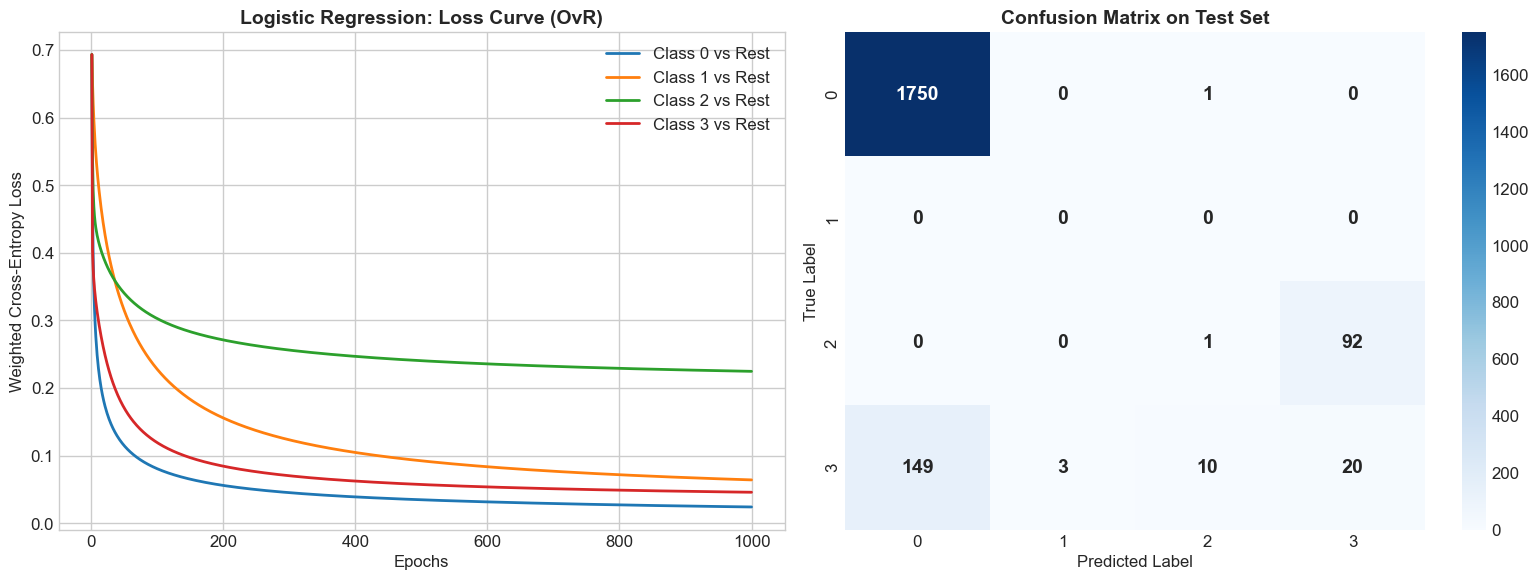

In [37]:
# Extract the best hyperparameters
best_penalty = best_params['penalty']
best_lambda = best_params['lambda_reg']

print(f"Training the final Multiclass Logistic Regression model with Penalty={best_penalty.upper()}, Lambda={best_lambda}...")

# Initialize final model using One-vs-Rest strategy
best_lr_model = OneVsRestClassifier(
    estimator_cls=LogisticRegression,
    learning_rate=0.1, 
    max_iter=1000, 
    penalty=best_penalty, 
    lambda_reg=best_lambda, 
    class_weight='balanced'
)

# Train on the full training set
best_lr_model.fit(X_train_scaled, y_train)
print("Training completed successfully.\n")

# Evaluate on the test set
y_pred_test_lr = best_lr_model.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_pred_test_lr)

print("-" * 55)
print(f"Final Model Test Accuracy: {test_acc_lr*100:.2f}%")
print("-" * 55)
print("Classification Report:")
# zero_division=0 prevents warnings if a class is completely missed
print(classification_report(y_test, y_pred_test_lr, zero_division=0))

# Visualizations: Loss Curve and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the Loss Curve for each of the 4 internal models
for idx, estimator in enumerate(best_lr_model.estimators_):
    axes[0].plot(range(1, len(estimator.loss_history) + 1), estimator.loss_history, 
                 linewidth=2, label=f'Class {best_lr_model.classes_[idx]} vs Rest')

axes[0].set_title('Logistic Regression: Loss Curve (OvR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Weighted Cross-Entropy Loss', fontsize=12)
axes[0].legend()

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=best_lr_model.classes_, 
            yticklabels=best_lr_model.classes_,
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

**Đánh giá thực tế mô hình Logistic Regression (OvR) trên tập Test:**

1. **Sự hội tụ của Loss Curve:** Đồ thị đường cong mất mát của 4 mô hình con (tương ứng với 4 lớp) đều giảm mượt mà và tiệm cận dần về mức ổn định. Điều này cho thấy thuật toán tối ưu Gradient Descent cùng chiến lược OvR đã hoạt động đúng đắn về mặt toán học.
2. **Góc khuất của con số Accuracy 87.41%:** Thoạt nhìn, độ chính xác tổng thể 87.41% có vẻ khá tốt. Tuy nhiên, khi đào sâu vào **Classification Report** và **Confusion Matrix**, nhóm phát hiện ra một sự mất cân bằng dữ liệu (data imbalance) cực kỳ nghiêm trọng trong tập Test:
   * Lớp 0 (phòng trống) chiếm áp đảo với 1751/2026 mẫu (chiếm hơn 86%).
   * Lớp 2 và 3 có số lượng mẫu rất ít, trong khi lớp 1 thậm chí không có bất kỳ mẫu nào để test (support = 0).
   * Con số Accuracy 87.41% thực chất phần lớn đến từ việc mô hình "dự đoán theo số đông". Nó chỉ cần đoán hầu hết là phòng trống (lớp 0) thì tự động điểm trung bình sẽ bị kéo lên cao.
3. **Giới hạn trong việc phân loại lượng người cụ thể:**
   Dù nhóm đã chủ động cấu hình `class_weight='balanced'` trong hàm huấn luyện để phạt nặng hơn nếu đoán sai lớp thiểu số, nhưng kết quả F1-score và Recall của lớp 2, 3 vẫn cực kỳ thấp (Recall lớp 2 chỉ 0.01, lớp 3 chỉ 0.11). Điều này chứng tỏ sự chênh lệch số lượng mẫu quá lớn đã hoàn toàn đánh gục cơ chế bù trọng số. Các đường biên ranh giới tuyến tính của Logistic Regression gặp khó khăn trong việc bóc tách các dải cảm biến giao thoa của số lượng người cụ thể (1, 2 hay 3 người) khi nó liên tục bị lớp 0 che mờ.

$\rightarrow$ **Kết luận:** Lõi thuật toán và các chiến lược xử lý đa lớp (OvO, OvR) đã được nhóm cài đặt chuẩn xác và hoạt động đúng với lý thuyết. Tuy nhiên, đối với bài toán chuỗi thời gian thực tế có độ lệch dữ liệu cao như đồ án này, các thuật toán phân lớp tuyến tính truyền thống tỏ ra đuối sức ở các lớp thiểu số. Để mô hình nhận diện chính xác số người, ta bắt buộc phải can thiệp bằng các kỹ thuật cân bằng dữ liệu (như SMOTE) hoặc ứng dụng các mô hình phi tuyến tính mạnh mẽ hơn (như Tree-based models).